In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB6
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE

2026-04-24 15:22:28.909570: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 15:22:29.330787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777044149.505823   29549 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777044149.544591   29549 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-24 15:22:29.939636: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Preprocessing and segregate

In [2]:
def preprocessing(path):
    img = Image.open(path)
    img_resized = img.resize((224,224))
    return np.array(img_resized)/255

In [3]:
data_path = '../data/spectrograms'
class0 = 'class_0'
class1 = 'class_1'

In [13]:
non_seizure = []
seizure = []
non_seizure_folders = []    # ← ADD
seizure_folders = []        # ← ADD

n_seizure_names = [f for f in os.listdir(os.path.join(data_path, class0))]
seizure_names = [f for f in os.listdir(os.path.join(data_path, class1))]

for path in n_seizure_names:
    non_seizure.append(preprocessing(os.path.join(data_path, class0, path)))
    # Filename starts with original folder letter e.g. 'A001.png' → 'A'
    non_seizure_folders.append(path[0].upper())    # ← ADD

for path in seizure_names:
    seizure.append(preprocessing(os.path.join(data_path, class1, path)))
    seizure_folders.append(path[0].upper())        # ← ADD

# Debug — see what your actual filenames look like
print("class_0 sample filenames:", n_seizure_names[:5])
print("class_1 sample filenames:", seizure_names[:5])

# See all unique first characters
print("\nUnique folder letters in non_seizure:", set(f[0].upper() for f in n_seizure_names))
print("Unique folder letters in seizure:", set(f[0].upper() for f in seizure_names))

class_0 sample filenames: ['Z075.png', 'O007.png', 'O089.png', 'F096.png', 'O067.png']
class_1 sample filenames: ['S027.png', 'S037.png', 'S020.png', 'S011.png', 'S095.png']

Unique folder letters in non_seizure: {'O', 'F', 'Z'}
Unique folder letters in seizure: {'S'}


In [14]:
non_seizure_labels = [0] * len(non_seizure)
seizure_labels = [1] * len(seizure)

data = non_seizure + seizure
data_labels = non_seizure_labels + seizure_labels
data_folders = non_seizure_folders + seizure_folders   # ← ADD

# Shuffle all three together
X, y, folders = shuffle(
    np.array(data),
    np.array(data_labels),
    np.array(data_folders),   # ← ADD
    random_state=42
)

# First split — keep folders in sync
X_train, X_test, y_train, y_test, folders_train, folders_test = train_test_split(
    X, y, folders, test_size=0.3, random_state=42
)

# Second split
X_test, X_val, y_test, y_val, folders_test, folders_val = train_test_split(
    X_test, y_test, folders_test, test_size=1/3, random_state=42
)

# One-hot encode (folders_test stays as-is — string array)
y_test = np.eye(2)[y_test]
y_val = np.eye(2)[y_val]

In [15]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (280, 224, 224, 4)
y_train shape: (280,)
X_test shape: (80, 224, 224, 4)
y_test shape: (80, 2)
X_val shape: (40, 224, 224, 4)
y_val shape: (40, 2)


## Applying SMOTE

In [7]:
X_flat = X_train.reshape((X_train.shape[0], -1))
smote=SMOTE(sampling_strategy='minority') 
X_train_resampled,y_train_resampled = smote.fit_resample(X_flat,y_train)
X_train = X_train_resampled.reshape((-1, 224, 224, 4))
y_train = np.eye(2)[y_train_resampled]

In [8]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (414, 224, 224, 4)
y_train shape: (414, 2)


## Model Creeation

In [16]:
base_model = EfficientNetB6(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 4),
    pooling='avg'
)

x = base_model.output
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)


/home/ricky/miniconda3/envs/CUDA/lib/python3.12/site-packages/keras/src/applications/efficientnet.py:289: UserWarning: This model usually expects 1 or 3 input channels. However, it was passed an input_shape with 4 input channels.
  input_shape = imagenet_utils.obtain_input_shape(


In [17]:
model.compile(optimizer = Adam(), loss = 'categorical_crossentropy', metrics = ['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '../weights/EfficientNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

## Model Training

In [11]:
history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size = 20,
        callbacks= [checkpoint]
    )

Epoch 1/30


I0000 00:00:1748853233.990538   19957 service.cc:148] XLA service 0x7fa4940025d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748853233.991098   19957 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-02 08:33:55.578136: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748853241.542101   19957 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-02 08:34:09.245314: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58463', 16 bytes spill stores, 16 bytes spill loads

2025-06-02 08:34:09.430659: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_584

20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.5656 - loss: 1.1212

2025-06-02 08:35:17.147968: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58463_0', 256 bytes spill stores, 256 bytes spill loads

2025-06-02 08:35:17.414031: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_62950', 8 bytes spill stores, 8 bytes spill loads

2025-06-02 08:35:29.833608: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng18{k11=0} for conv (f32[240,1,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,240,56,56]{3,2,1,0}, f32[14,240,56,56]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=240, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule"

21/21 ━━━━━━━━━━━━━━━━━━━━ 189s 4s/step - accuracy: 0.5634 - loss: 1.1153 - val_accuracy: 0.2250 - val_loss: 1.2773
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.5883 - loss: 1.1176 - val_accuracy: 0.2250 - val_loss: 216.4315
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.7950 - loss: 0.5083 - val_accuracy: 0.7750 - val_loss: 1186.4011
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.8843 - loss: 0.4824 - val_accuracy: 0.2250 - val_loss: 7.4330
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 311ms/step - accuracy: 0.9337 - loss: 0.2196 - val_accuracy: 0.2250 - val_loss: 12.8719
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 239ms/step - accuracy: 0.9211 - loss: 0.2157 - val_accuracy: 0.2250 - val_loss: 117.7212
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step - accuracy: 0.9773 - loss: 0.0855 - val_accuracy: 0.7750 - val_loss: 2.2554
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.9285 - loss: 0.2261 - val_accuracy: 0.2250

## Accuracy

In [18]:
model.load_weights('../weights/EfficientNet.weights.h5')
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.9312 - loss: 0.2159
Test Loss: 0.23312480747699738
Test Accuracy: 0.925000011920929


3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 15s/step
Label distribution per group:
patient_type     label_value
epileptic_nonsz  0              17
epileptic_sz     1              18
healthy          0              45
dtype: int64

  attribute_name  attribute_value  group_size       tpr       fpr       fnr  \
0   patient_type  epileptic_nonsz          17       NaN  0.058824       NaN   
1   patient_type     epileptic_sz          18  0.777778       NaN  0.222222   
2   patient_type          healthy          45       NaN  0.022222       NaN   

        tnr  
0  0.941176  
1       NaN  
2  0.977778  
  attribute_name  attribute_value       fpr  fpr_disparity       tpr  \
0   patient_type  epileptic_nonsz  0.058824       2.647059       NaN   
1   patient_type     epileptic_sz       NaN            NaN  0.777778   
2   patient_type          healthy  0.022222       1.000000       NaN   

   tpr_disparity       fnr  fnr_disparity  
0            NaN       NaN            NaN  
1            NaN  0.222222        

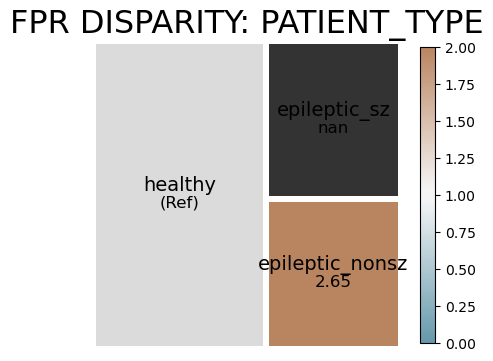

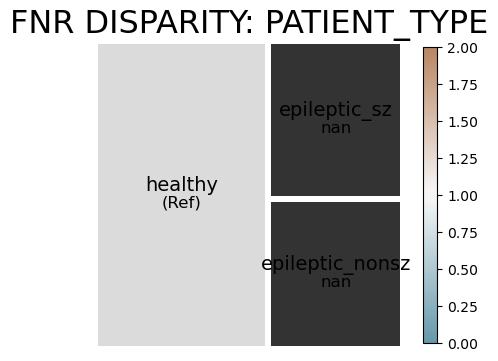

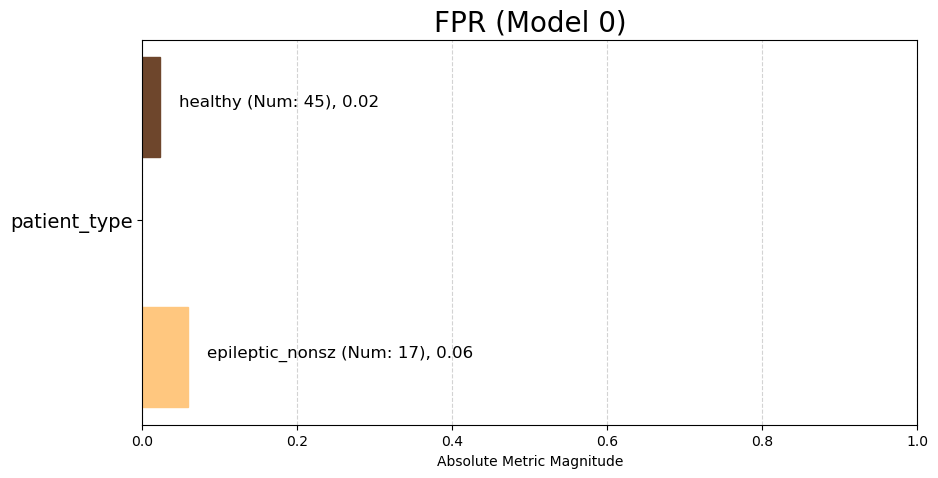

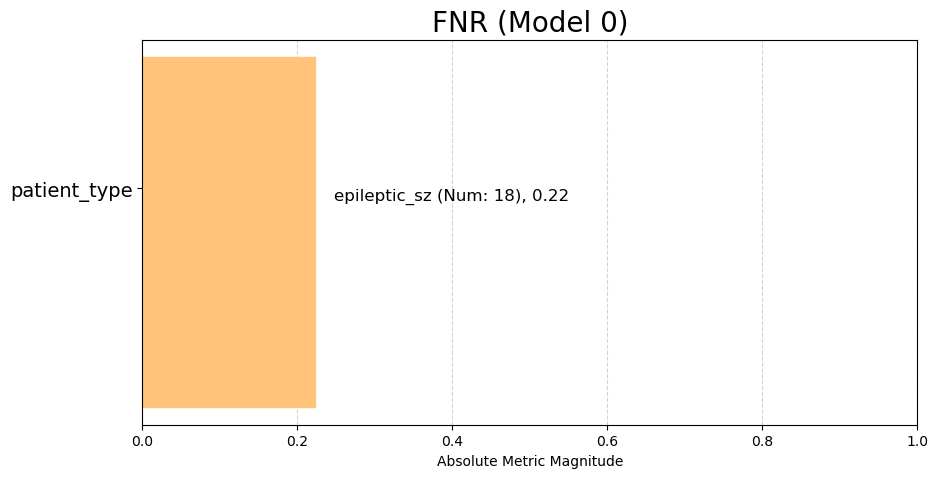

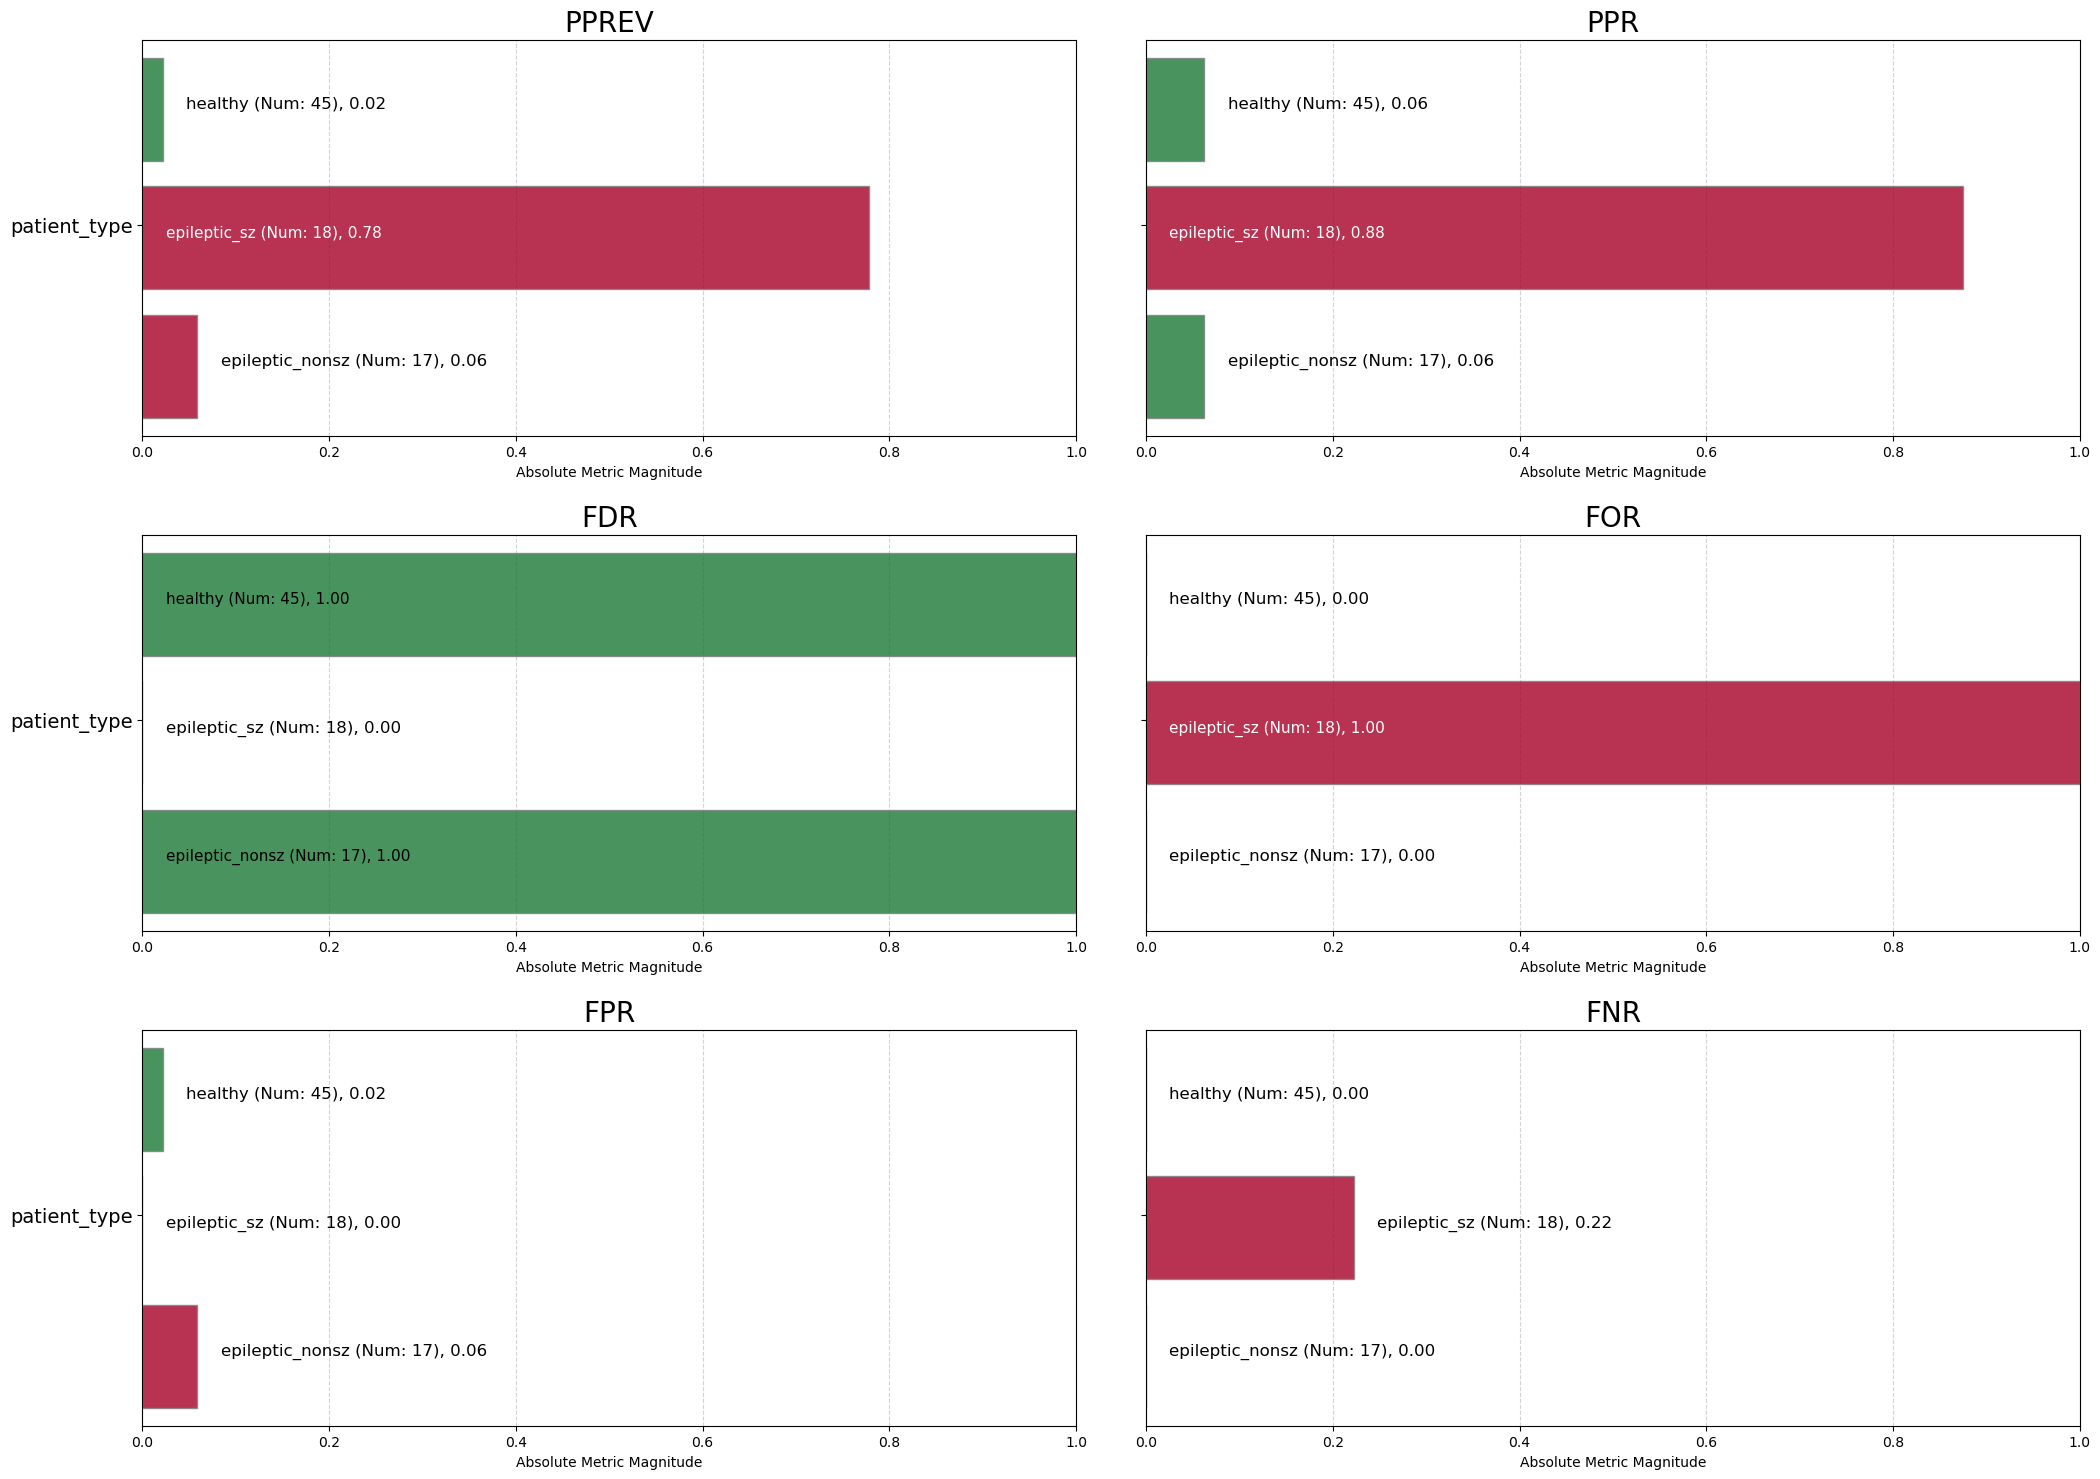

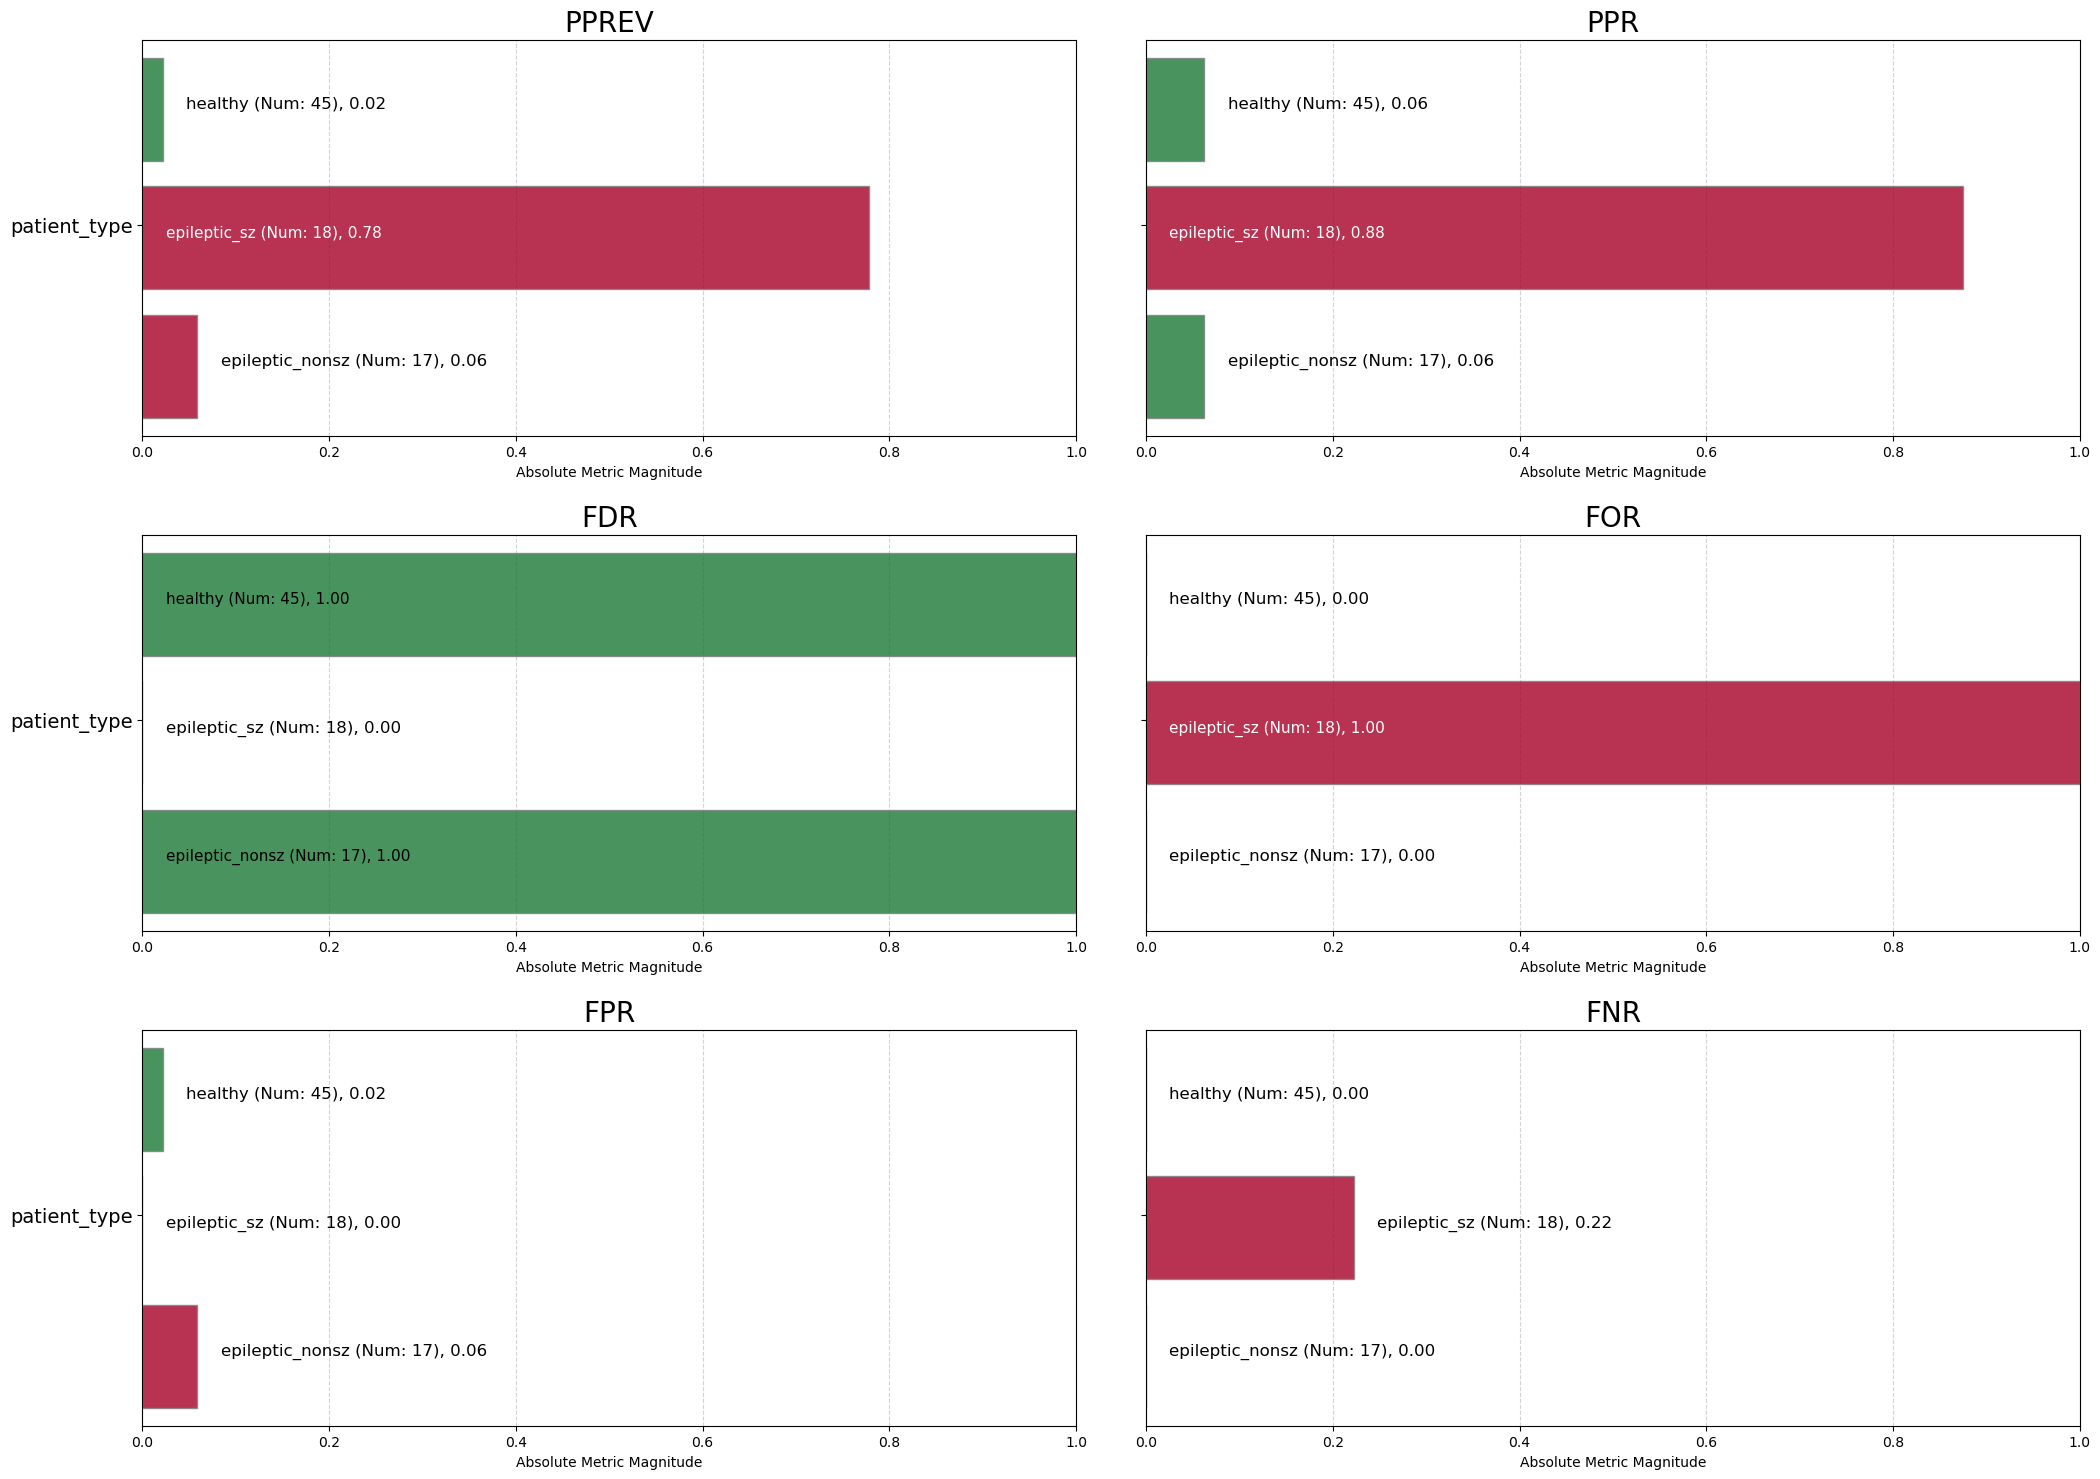

<Figure size 640x480 with 0 Axes>

In [19]:
import pandas as pd
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
from aequitas.plotting import Plot

# ── 1. Get predictions ───────────────────────────────────────────────────────
# EfficientNet model.predict returns (n, 2) directly — no unpacking needed
model.load_weights('../weights/EfficientNet.weights.h5')
y_pred_probs = model.predict(X_test)               # shape: (n, 2)
y_pred_classes = np.argmax(y_pred_probs, axis=1)   # shape: (n,)
y_test_classes = np.argmax(y_test, axis=1)         # shape: (n,)

# ── 2. Map folders to patient types ─────────────────────────────────────────
patient_type_map = {
    'Z': 'healthy',          # healthy, eyes open       → label 0
    'O': 'healthy',          # healthy, eyes closed     → label 0
    'N': 'epileptic_nonsz',  # epileptic, non-sz zone   → label 0
    'F': 'epileptic_nonsz',  # epileptic, seizure zone  → label 0
    'S': 'epileptic_sz'      # actively seizing         → label 1
}
patient_types = np.array([patient_type_map[f] for f in folders_test])

# ── 3. Build Aequitas DataFrame ──────────────────────────────────────────────
aequitas_df = pd.DataFrame({
    'score':         y_pred_classes.astype(int),
    'label_value':   y_test_classes.astype(int),
    'patient_type':  patient_types,
    'source_folder': folders_test
})

# Sanity check — each group should only have one label
print("Label distribution per group:")
print(aequitas_df.groupby(['patient_type', 'label_value']).size())
print()

# ── 4. Group-level metrics ───────────────────────────────────────────────────
g = Group()
xtab, _ = g.get_crosstabs(aequitas_df, attr_cols=['patient_type'])
print(xtab[[
    'attribute_name', 'attribute_value',
    'group_size', 'tpr', 'fpr', 'fnr', 'tnr'
]])

# ── 5. Disparity (reference = healthy) ──────────────────────────────────────
b = Bias()
bdf = b.get_disparity_predefined_groups(
    xtab,
    original_df=aequitas_df,
    ref_groups_dict={'patient_type': 'healthy'}
)
print(bdf[[
    'attribute_name', 'attribute_value',
    'fpr', 'fpr_disparity',
    'tpr', 'tpr_disparity',
    'fnr', 'fnr_disparity'
]])

# ── 6. Fairness assessment ───────────────────────────────────────────────────
f = Fairness()
fdf = f.get_group_value_fairness(bdf)
print("\nFairness Summary:")
print(fdf[[
    'attribute_name', 'attribute_value',
    'TPR Parity', 'FDR Parity', 'FPR Parity', 'FNR Parity'
]].to_string(index=False))

fair_results = f.get_overall_fairness(fdf)
print("\nOverall Fairness:", fair_results)

# ── 7. Plots ─────────────────────────────────────────────────────────────────
aqp = Plot()
aqp.plot_disparity(bdf, 'fpr_disparity', 'patient_type')
aqp.plot_disparity(bdf, 'fnr_disparity', 'patient_type')
aqp.plot_group_metric(xtab, 'fpr')
aqp.plot_group_metric(xtab, 'fnr')
aqp.plot_fairness_group_all(fdf, ncols=2)